<a href="https://colab.research.google.com/github/Sharddha-Sharddha/IITMLAssignments/blob/main/AMAZON_fine_food_review_RNN%7CLSTM_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **#Amazon Fine Food Reviews**
Analyze ~500,000 food reviews from Amazon

This project is a Sentiment Analysis pipeline using the Amazon Fine Food Reviews dataset.


* **Goal**: To predict whether a food review is positive or negative based on the text.

* **Process**: You cleaned the text (removing HTML, special characters), tokenized it into numbers, and padded the sequences so they all have the same length.

* **Experiment**: built three different types of "**Recurrent**" Neural Networks (**SimpleRNN, LSTM, GRU , Bidirectionla GRU and Bidirectional LSTM** ) to compare which one is best at understanding the "context" and "order" of words in a review.




In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

os is used to connect directly with the dataset by taking the cache

In [73]:
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
csv_file = os.path.join(path,'Reviews.csv')
df = pd.read_csv(csv_file)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.


In [74]:
df.head(2)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...


In [75]:
df.shape

(568454, 10)

In [76]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


we only need user's text and score

In [77]:
df_clean = df[['Score','Text']]

In [78]:
df_clean

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...
...,...,...
568449,5,Great for sesame chicken..this is a good if no...
568450,2,I'm disappointed with the flavor. The chocolat...
568451,5,"These stars are small, so you can give 10-15 o..."
568452,5,These are the BEST treats for training and rew...


In [79]:
df_clean.isnull().sum()

,0
Score,0
Text,0


In [80]:
df_clean['Text'][2]

'This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis\' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.'

In [81]:
df_clean['Score'][2]

np.int64(4)

In [82]:
#rating distribution
score_counts = df_clean['Score'].value_counts().sort_index()
print('\nPercentage')
for score, count in score_counts.items():
  perc = (count/len(df_clean)) * 100
  print(f"{score} 🌟 : {perc:.2f}%")


Percentage
1 🌟 : 9.19%
2 🌟 : 5.24%
3 🌟 : 7.50%
4 🌟 : 14.19%
5 🌟 : 63.88%


we can clearly see there is a data emblance

Q: which product is given more preference and which product gives less preference

In [83]:
product_stat= df.groupby('ProductId')['Score'].agg(['mean', 'count'])

most_preferred= product_stat[product_stat['count']>50].sort_values(by='mean', ascending=False)
most_preferred.head(1)


,mean,count
ProductId,,
B000ED9L9E,4.973451,113


In [84]:
least_preferred= product_stat[product_stat['count']>50].sort_values(by='mean', ascending=True)
least_preferred.head(1)

,mean,count
ProductId,,
B006N3I69A,1.343511,131


In [85]:
for score in [1,2,3,4,5]:
  sample_review = df_clean[df_clean['Score'] == score]['Text'].iloc[0]
  print(f"\n🌟 {score}-STAR reviews")
  print(f"'{sample_review}'")


🌟 1-STAR reviews
'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".'

🌟 2-STAR reviews
'If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.'

🌟 3-STAR reviews
'This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't buy it again.'

🌟 4-STAR reviews
'This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly 

In [86]:
df_clean['text_length'] = df_clean['Text'].str.len()
df_clean['word_count'] = df_clean['Text'].str.split().str.len()

/tmp/ipykernel_13075/1053056101.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['text_length'] = df_clean['Text'].str.len()
/tmp/ipykernel_13075/1053056101.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['word_count'] = df_clean['Text'].str.split().str.len()


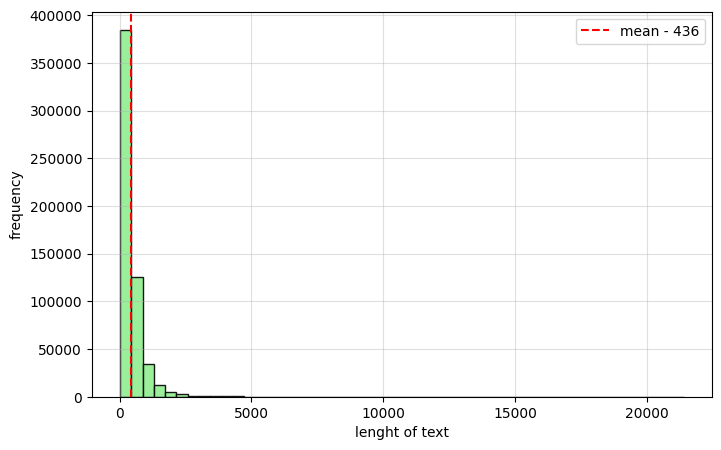

In [87]:
plt.figure(figsize=(8,5))
plt.hist(df_clean['text_length'], bins= 50, color= 'lightgreen', alpha= 0.9, edgecolor= 'black')
plt.grid(alpha= 0.4)
plt.xlabel('lenght of text')
plt.ylabel('frequency')
plt.axvline(df_clean['text_length'].mean(), linestyle= '--', color = 'red', label = (f'mean - {df_clean['text_length'].mean() :.0f}'))
plt.legend()
plt.show()

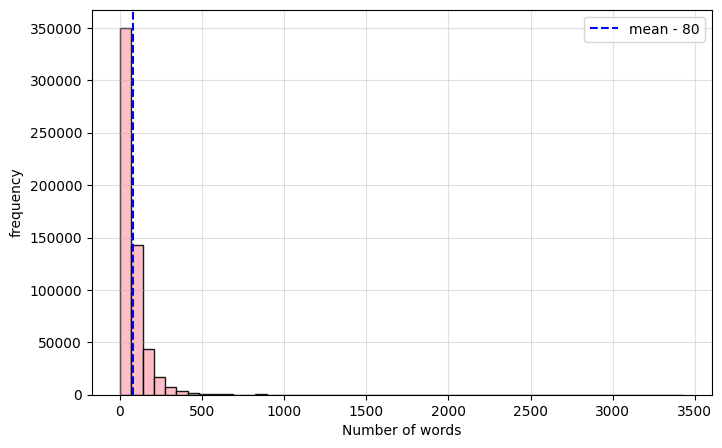

In [88]:
plt.figure(figsize=(8,5))
plt.hist(df_clean['word_count'], bins= 50, color= 'lightpink', alpha= 0.9, edgecolor= 'black')
plt.grid(alpha= 0.4)
plt.xlabel('Number of words')
plt.ylabel('frequency')
plt.axvline(df_clean['word_count'].mean(), linestyle= '--', color = 'blue', label = (f'mean - {df_clean['word_count'].mean() :.0f}'))
plt.legend()
plt.show()

# divide the data for scoring
1,2 - neg - 0

4,5 - pos - 1

3 = removed all 3 my data , confused

In [89]:
df_binary = df_clean[df_clean['Score']!= 3].copy()
df_binary['sentiment'] = (df_binary['Score']>=4).astype(int)
df_binary

,Score,Text,text_length,word_count,sentiment
0,5,I have bought several of the Vitality canned d...,263,48,1
1,1,Product arrived labeled as Jumbo Salted Peanut...,190,31,0
2,4,This is a confection that has been around a fe...,509,94,1
3,2,If you are looking for the secret ingredient i...,219,41,0
4,5,Great taffy at a great price. There was a wid...,140,27,1
...,...,...,...,...,...
568449,5,Great for sesame chicken..this is a good if no...,149,26,1
568450,2,I'm disappointed with the flavor. The chocolat...,252,46,0
568451,5,"These stars are small, so you can give 10-15 o...",372,66,1
568452,5,These are the BEST treats for training and rew...,200,35,1


In [90]:
print(f"Original Dataset : {len(df_clean):,} reviews")
print(f"After removing 3 start revi : {len(df_binary):,} reviews")
print(f"\nClass Distribution")
print(f"Negative (1-2 stars) : {sum(df_binary['sentiment']==0):,}")
print(f"Positive (4-5 stars) : {sum(df_binary['sentiment']==1):,}")
print(f"\nClass Distribution Percentage")
neg_pct = (sum(df_binary['sentiment']==0) / len(df_binary)) * 100
pos_pct = (sum(df_binary['sentiment']==1) / len(df_binary)) * 100
print(f"Negative (1-2 stars) in % : {neg_pct:.2f}%")
print(f"Negative (4-5 stars) in % : {pos_pct:.2f}%")

Original Dataset : 568,454 reviews
After removing 3 start revi : 525,814 reviews

Class Distribution
Negative (1-2 stars) : 82,037
Positive (4-5 stars) : 443,777

Class Distribution Percentage
Negative (1-2 stars) in % : 15.60%
Negative (4-5 stars) in % : 84.40%


In [91]:
#there is a clear class imbalance, heavy imbalance

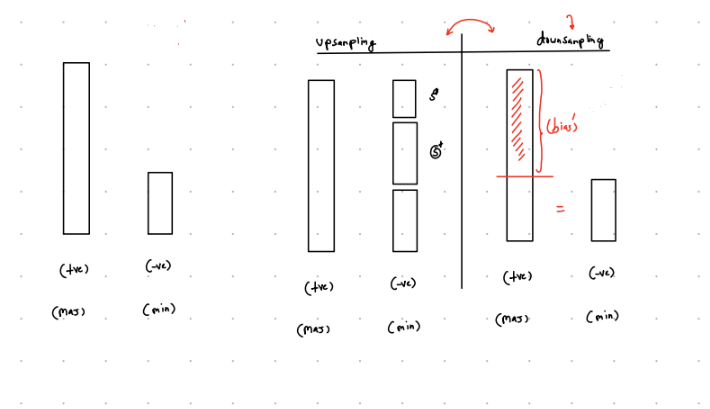

In [92]:
from sklearn.utils import resample

In [93]:
negative_review = df_binary[df_binary['sentiment']==0]
positive_review = df_binary[df_binary['sentiment']==1]

len(negative_review)

82037

In [94]:
len(positive_review)

443777

In [95]:
#downampling
n_minor = len(negative_review)
positive_downsampaled = resample(positive_review,
                                 replace = False, # duplicates are avoided
                                 n_samples = n_minor)

In [96]:
df_balanced = pd.concat([positive_downsampaled,negative_review])
#shuffles the entire dataset
df_balanced = df_balanced.sample(frac= 1).reset_index(drop = True)

In [97]:
df_balanced.head(2)

,Score,Text,text_length,word_count,sentiment
0,4,"About 2 Jars into this delicious creation, my ...",237,43,1
1,5,I really love chocolate but have been trying t...,620,113,1


In [98]:
df_balanced.head(15)

,Score,Text,text_length,word_count,sentiment
0,4,"About 2 Jars into this delicious creation, my ...",237,43,1
1,5,I really love chocolate but have been trying t...,620,113,1
2,1,The one lb. tin is well packed and melded toge...,414,72,0
3,5,the tea is very good with honey and I have see...,95,20,1
4,1,"I placed an order for $28.95, expecting to get...",101,19,0
5,5,"Yeah, this gopher trap is pretty amazing!<br /...",1778,328,1
6,5,Instead of Simple Solution Lamb & Rice I was s...,216,46,1
7,1,"I bought a jar of pimentos yesterday, opened i...",553,106,0
8,1,"I love the regular sleepy time, and I love van...",215,41,0
9,1,Used to have this all the time. It's not avai...,366,68,0


In [99]:
print(f'-ve -> {sum(df_balanced['sentiment']==0)} ({sum(df_balanced['sentiment']==0)/len(df_balanced)* 100:.1f})')
print(f'+ve -> {sum(df_balanced['sentiment']==1)} ({sum(df_balanced['sentiment']==1)/len(df_balanced)* 100:.1f})')

-ve -> 82037 (50.0)
+ve -> 82037 (50.0)


In [100]:
df_balanced.shape

(164074, 5)

In [101]:
sample_size = 50000
df_sample = df_balanced.sample(n=sample_size)

In [102]:
df_sample.shape

(50000, 5)

In [103]:
#still 50,000 seperate sample - check on balance
sample_neg = sum(df_sample['sentiment']==0)
sample_pos =sum(df_sample['sentiment']==1)
print(f"\nClass Distribution")
print(f"Negative : {sample_neg:,} ({sample_neg/len(df_sample)*100:.2f}%)")
print(f"Positive : {sample_pos:,} ({sample_pos/len(df_sample)*100:.2f}%)")


Class Distribution
Negative : 25,214 (50.43%)
Positive : 24,786 (49.57%)


In [104]:
import re # regular expresion

In [105]:
#text processing
df_sample['Text'].iloc[4]

"I've been using this pepper for several years. My previous source stopped carrying it, and I found it at Amazon. I often freshly grind pepper for cooking but find this product to be fresh and tasty. Amazon's ordering process is easy, and this pepper ships for free from Amazon if I order it with something else that tops the $25 thresh hold."

Replacing the html tags and special symbols by blank space
<       : Start of tag

[^>]+   : One or more characters that are NOT '>'

'>'       : End of tag

In [106]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'<[^>]+>',' ', text) # catching all the tag and replace with empty space
  text = re.sub(r'[^a-zA-Z\s]', ' ', text) #anything which is not a-z/A-Z or blank space \s remove them
  return text

In [107]:
clean_text(df_sample['Text'].iloc[4])

'i ve been using this pepper for several years  my previous source stopped carrying it  and i found it at amazon  i often freshly grind pepper for cooking but find this product to be fresh and tasty  amazon s ordering process is easy  and this pepper ships for free from amazon if i order it with something else that tops the     thresh hold '

In [108]:
df_sample['clean_text'] = df_sample['Text'].apply(clean_text)

In [109]:
df_sample.head(2)

,Score,Text,text_length,word_count,sentiment,clean_text
151863,5,"Great product, will buy it again. I've purcha...",188,31,1,great product will buy it again i ve purcha...
56390,5,"Lowrey's Bacon Curls Microwave Pork Rinds, Hot...",135,22,1,lowrey s bacon curls microwave pork rinds hot...


In [110]:
MAX_FEATURES = 10000 #from al lthe data i need a vocab of size 10,000
MAX_LEN = 100 #standard


In [111]:
import tensorflow as tf

In [112]:
!pip install keras

In [113]:
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pickle

In [114]:
X = df_sample['clean_text'].values #Features
y = df_sample['sentiment'].values

In [115]:
tokenizers=  Tokenizer(num_words = MAX_FEATURES, oov_token = '<OOV>')
tokenizers.fit_on_texts(X)

X_sequence = tokenizers.texts_to_sequences(X)
X_padded = pad_sequences(X_sequence,
                         maxlen = MAX_LEN,
                         padding = 'post',
                         truncating = 'post')

In [116]:
print(X[1])

lowrey s bacon curls microwave pork rinds  hot   spicy       ounce packages  pack of      pork rinds are great with beer  love it 


In [117]:
# See the first 10 words in our dictionary
print(list(tokenizers.word_index.items())[:11])

[('<OOV>', 1), ('the', 2), ('i', 3), ('and', 4), ('a', 5), ('it', 6), ('to', 7), ('of', 8), ('this', 9), ('is', 10), ('in', 11)]


In [118]:
print(f'text to sequence converted : \n{X[1].split()}\n{X_sequence[1]}')

text to sequence converted : 
['lowrey', 's', 'bacon', 'curls', 'microwave', 'pork', 'rinds', 'hot', 'spicy', 'ounce', 'packages', 'pack', 'of', 'pork', 'rinds', 'are', 'great', 'with', 'beer', 'love', 'it']
[7860, 24, 1274, 4982, 956, 1491, 3563, 179, 563, 442, 636, 185, 8, 1491, 3563, 23, 57, 20, 1495, 65, 6]


In [119]:
print(len(X_sequence[1]))

21


In [120]:
print(len(X[1].split()))

21


In [121]:
print(X_padded[1])

[7860   24 1274 4982  956 1491 3563  179  563  442  636  185    8 1491
 3563   23   57   20 1495   65    6    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [122]:
#train test split
# we split the data into training and testing-> we do this to avoid data leakage!

In [123]:
x_train,x_test,y_train,y_test = train_test_split(X_padded,y,
                                                 test_size= 0.2,
                                                 stratify = y)

In [124]:
x_train.shape

(40000, 100)

In [125]:
x_test.shape

(10000, 100)

In [126]:
train_pos= sum(y_train)
test_pos = sum(y_test)
print(f' number of Positive reviews in training data: {train_pos}')
print(f' number of Positive reviews in testing data: {test_pos}')

 number of Positive reviews in training data: 19829
 number of Positive reviews in testing data: 4957


In [127]:
# - Embedding layer - convert word indices to dense vector,The Embedding layer turns meaningless numbers (IDs) into meaningful math (Vectors).
# - RNN - process sequences
# - Dropout layer - prevents overfitting
# - Dense layer - classification

**SimpleRNN**:  The basic version of a recurrent model; it processes words in order but has a 'short memory' for long sentences.

In [128]:
def create_RNN_model():
  model= Sequential([
      Embedding(input_dim= MAX_FEATURES,  # "I know 10,000 unique words."
                output_dim= 128,          # "I will describe each word using 128 coordinates."
                input_length= MAX_LEN),      # "Every review I read will be exactly 150 words long."
      SimpleRNN(units=64, return_sequences= False),
      Dropout(0.5),
      Dense(32, activation = 'relu'),
      Dense(1,activation = 'sigmoid')
  ])
  return model

In [129]:
from sklearn import metrics
RNN_model = create_RNN_model()
RNN_model.compile(optimizer = 'adam',
                  metrics = ['accuracy'],
                  loss = 'binary_crossentropy')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [130]:
earlyl_stoping = EarlyStopping (
    monitor= 'val_loss',
    patience=5,
    restore_best_weights= True,
    verbose = 1
    )
#model checkpoints

rnn_checkpoints = ModelCheckpoint(
    'best_RNN_model.keras',
    monitor= 'val_accuracy',
    save_best_only = True,
    verbose =1,
    mode = 'max',
)

In [131]:
RNN_history = RNN_model.fit(
    x_train,y_train,
    batch_size = 128,
    epochs = 10,
    validation_split = 0.20,
    callbacks= [earlyl_stoping, rnn_checkpoints]
)

Epoch 1/10
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5029 - loss: 0.6991
Epoch 1: val_accuracy improved from None to 0.52513, saving model to best_RNN_model.keras

Epoch 1: finished saving model to best_RNN_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.5103 - loss: 0.6963 - val_accuracy: 0.5251 - val_loss: 0.6912
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5531 - loss: 0.6809
Epoch 2: val_accuracy improved from 0.52513 to 0.54387, saving model to best_RNN_model.keras

Epoch 2: finished saving model to best_RNN_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5553 - loss: 0.6782 - val_accuracy: 0.5439 - val_loss: 0.6827
Epoch 3/10
246/250 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6170 - loss: 0.6286
Epoch 3: val_accuracy did not improve from 0.54387
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6103 - loss: 0.6280 - val_accuracy: 0.5238 - val_loss: 0.7236
Epoch 4/10
246/250 ━━━━━━━━━━━━━━━━━━━

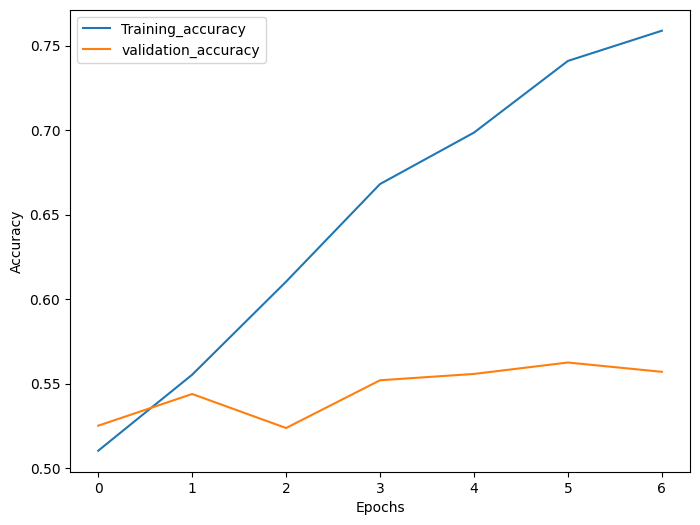

In [132]:
plt.figure(figsize = (8,6))
plt.plot(RNN_history.history['accuracy'], label = 'Training_accuracy')
plt.plot(RNN_history.history['val_accuracy'], label = 'validation_accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

**LSTM (Long Short-Term Memory):** An upgraded RNN with a '**cell state**' that allows it to remember important words from the beginning of a long review.

In [ ]:
def create_Lstm_model():
  model_1 = Sequential([
      Embedding(input_dim= MAX_FEATURES,
                   output_dim= 128,
                   input_length = MAX_LEN),
      LSTM(units = 64, return_sequences= False),
      Dropout(0.50),
      Dense(32, activation= 'relu'),
      Dense(1, activation= 'sigmoid' )
  ])
  return model_1

lstm_model = create_Lstm_model()
lstm_model.compile(
    optimizer= 'adam',
    metrics= ['accuracy'],
    loss= 'binary_crossentropy'
)

lstm_checkpoints = ModelCheckpoint(
    'best_lstm_model.keras',
    monitor= 'val_accuracy',
    save_best_only = True,
    verbose =0,
    mode = 'max',
)
#fit model
lstm_model_history = lstm_model.fit(
    x_train, y_train,
    batch_size = 128,
    epochs = 10,
    validation_split = 0.20,
    callbacks = [earlyl_stoping, lstm_checkpoints]
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5499 - loss: 0.6749 - val_accuracy: 0.6898 - val_loss: 0.5969
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6184 - loss: 0.6371 - val_accuracy: 0.5626 - val_loss: 0.6722
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6203 - loss: 0.6486 - val_accuracy: 0.6649 - val_loss: 0.6263
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6627 - loss: 0.6083 - val_accuracy: 0.7509 - val_loss: 0.5381
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8103 - loss: 0.4468 - val_accuracy: 0.8229 - val_loss: 0.4162
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8672 - loss: 0.3459 - val_accuracy: 0.8430 - val_loss: 0.3679
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8965 - loss: 0.2873 - val_accuracy: 0.8539 - val_loss: 0.3718
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9090 - loss: 0.2594 - val_accura

In [ ]:
#plot the model
plt.figure(figsize=(6,4))
plt.plot(lstm_model_history.history['accuracy'],label='Training accuracy')
plt.plot(lstm_model_history.history['val_accuracy'],label='Val accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()

GRU Model

In [ ]:
def create_gru_model():
  model_3 = Sequential([
      Embedding(input_dim= MAX_FEATURES,
                   output_dim= 128,
                   input_length = MAX_LEN),
      GRU(units= 64, return_sequences= False),
      Dropout(0.50),
      Dense(32, activation='relu'),
      Dense(1, activation= 'sigmoid')
  ])
  return model_3


gru_model = create_gru_model()
gru_model.compile(
    optimizer= 'adam',
    metrics= ['accuracy'],
    loss = 'binary_crossentropy'
)

gru_checkpoints = ModelCheckpoint(
    'best_gru_model.keras',
    monitor= 'val_accuracy',
    save_best_only = True,
    verbose =1,
    mode = 'max',
)

gru_model_history= gru_model.fit(
    x_train, y_train,
    batch_size= 128,
    epochs= 10,
    validation_split= 0.20,
    callbacks = [earlyl_stoping, gru_checkpoints]
)

In [ ]:
plt.figure(figsize= (8,5))
plt.plot(gru_model_history.history['accuracy'], label= 'Accuracy')
plt.plot(gru_model_history.history['val_accuracy'], label= 'val_Accuracy')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Bidirectional LSTM**: Reads the review **forward AND backward** simultaneously to catch the full context from both ends of a sentence.

In [ ]:
def create_bilstm_model():
  model_4= Sequential([
      Embedding(input_dim= MAX_FEATURES,
                output_dim= 128,
                input_length= MAX_LEN),
      Bidirectional(LSTM(64, return_sequences= True)),
      Dropout(0.50),
      Bidirectional(LSTM(64)),
      Dropout(0.50),
      Dense(1, activation= 'sigmoid')
  ])
  return model_4

bilstm_model= create_bilstm_model()

#compile
bilstm_model.compile(
    optimizer = 'adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bilstm_checkpoints = ModelCheckpoint(
    'best_bilstm_model.keras',
    monitor= 'val_accuracy',
    save_best_only = True,
    verbose =1,
    mode = 'max',
)

#fit
bilstm_model_history= bilstm_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs= 10,
    validation_split= 0.20,
   callbacks = [earlyl_stoping, bilstm_checkpoints]
)




In [ ]:
#plot the model
plt.figure(figsize=(6,4))
plt.plot(bilstm_model_history.history['accuracy'],label='Training accuracy')
plt.plot(bilstm_model_history.history['val_accuracy'],label='Val accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()

BI-GRU model

In [ ]:
def create_bigru_model():
  model_4= Sequential([
      Embedding(input_dim= MAX_FEATURES,
                output_dim= 128,
                input_length= MAX_LEN),
      Bidirectional(GRU(64, return_sequences= True)),
      Dropout(0.50),
      Bidirectional(GRU(64)),
      Dropout(0.50),
      Dense(1, activation= 'sigmoid')
  ])
  return model_4

bigru_model= create_bigru_model()

#compile
bigru_model.compile(
    optimizer = 'adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bigru_checkpoints = ModelCheckpoint(
    'best_bigru_model.keras',
    monitor= 'val_accuracy',
    save_best_only = True,
    verbose =1,
    mode = 'max',
)

#fit
bigru_model_history= bigru_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs= 10,
    validation_split= 0.20,
    callbacks = [earlyl_stoping, bigru_checkpoints]
)


In [ ]:
#plot the model
plt.figure(figsize=(6,4))
plt.plot(bigru_model_history.history['accuracy'],label='Training accuracy')
plt.plot(bigru_model_history.history['val_accuracy'],label='Val accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()

In [ ]:
!rm -rf my_dir

In [ ]:
model_dict= {'RNN model': RNN_model,
             'LSTM model': lstm_model,
             'GRU model': gru_model,
             'Bidirectional-lstm': bilstm_model,
             'bigru model': bigru_model}

fig, ax = plt.subplots(1,5, figsize= (25,5))
for axes, (modelname,model) in zip(ax, model_dict.items()):

  # Predict probabilities on the unseen test data
  y_pred = model.predict(x_test, verbose= 0)

  # Convert probabilities to binary classes (0 or 1) and convert it to 1-d(flatten())
  y_pred_class = (y_pred>=0.5).astype(int).flatten()

   # Generate the confusion matrix
  cm = confusion_matrix(y_test, y_pred_class)


  sns.heatmap(cm, annot = True, ax=axes, cbar= False,fmt='d', cmap='plasma',
              xticklabels=['negative','positive'],
              yticklabels=['negative','positive'])

  axes.set_title(f'{modelname} Prediction')
  axes.set_xlabel('predicted reviews')
  axes.set_ylabel('Actual reviews')
  plt.show()
  print('='*60)
  print(f'------------{modelname}-------------\n')
  print(classification_report(y_test,y_pred_class))
  print()

plt.tight_layout()


In [ ]:
for model_name,model in model_dict.items():
  print(f'------------{model_name}-------------\n')
  print(classification_report(y_test,y_pred_class))
  print()